In [11]:
import cv2
import h5py
import matplotlib.pyplot as plt
import os
from pathlib import Path
import numpy as np
import pandas as pd

from scipy.stats import median_abs_deviation
from PIL import Image

from MirrorFeatureExtractor.mirror_feature_extractor import (
    extract_glcm_features,
    extract_lbp_features,
    extract_edge_features
)

from MirrorExtractor.simple_mirror_extractor import SimpleMirrorExtractor

In [17]:
DIR_PATH = Path("/media/pgliwny/ADATA HD3303/Computer_Vision_system/data/MAGIC/webcam_useful_images")

features_keys_list = [
    'glcm_contrast', 'glcm_dissimilarity', 'glcm_homogeneity', 'glcm_energy', 'glcm_correlation', 
    'lbp_entropy', 'lbp_uniformity',
    'sobel_mean', 'laplacian_mean', 'laplacian_std', 'edge_density'
]

# Feature keys in guaranteed order
GLCM_KEYS = [
    'glcm_contrast', 'glcm_dissimilarity', 'glcm_homogeneity',
    'glcm_energy', 'glcm_correlation',
]

LBP_KEYS = ['lbp_entropy', 'lbp_uniformity']
EDGE_KEYS = ['sobel_mean', 'laplacian_mean', 'laplacian_std', 'edge_density']

ALL_FEATURE_KEYS = GLCM_KEYS + LBP_KEYS + EDGE_KEYS

In [18]:
# ── load baseline ───────────────────────────────────────────────
with h5py.File("../../Computer_Vision_system/data/baseline/baseline_webcam_features.h5", "r") as f:
    features = f["feature_matrix"][:]        # (n_images, 249, 11)
    valid = f["valid_mask"][:]               # (n_images, 249)
    names = [n.decode() for n in f["features_name"][:]]
    filenames = [n.decode() for n in f["image_filenames"][:]]
    
    # metadata
    print(f"Created: {f.attrs['created_at']}")
    print(f"Shape:   {features.shape}  →  {len(filenames)} images × {features.shape[1]} mirrors × {len(names)} features")

# ── quick sanity check ──────────────────────────────────────────
print(f"Valid:   {valid.sum()} / {valid.size} ({100*valid.mean():.1f}%)")
print(f"NaNs:    {np.isnan(features).sum()}")

# ── flatten to DataFrame for EDA ────────────────────────────────
# one row per (image, mirror) pair
idx = np.argwhere(valid)  # only valid entries
rows = features[idx[:, 0], idx[:, 1], :]

df = pd.DataFrame(rows, columns=names)
df["image_idx"] = idx[:, 0]
df["mirror_id"] = idx[:, 1]
df["filename"] = df["image_idx"].map(dict(enumerate(filenames)))

df.head()

Created: 2026-04-27T14:38:44.335717+00:00
Shape:   (71, 249, 11)  →  71 images × 249 mirrors × 11 features
Valid:   17679 / 17679 (100.0%)
NaNs:    0


,glcm_contrast,glcm_dissimilarity,glcm_homogeneity,glcm_energy,glcm_correlation,lbp_entropy,lbp_uniformity,sobel_mean,laplacian_mean,laplacian_std,edge_density,image_idx,mirror_id,filename
0,3918.074463,38.408302,0.198675,0.178041,0.573408,2.781074,0.356209,8.914062,107.921570,82.865990,0.274510,0,0,image_2023-04-18_1500.jpg
1,4756.646484,44.083706,0.230735,0.209625,0.560718,2.725035,0.386842,9.062500,115.199997,83.081017,0.305263,0,1,image_2023-04-18_1500.jpg
2,4031.899902,37.627701,0.221094,0.199353,0.586815,2.744304,0.388158,8.843750,108.631577,84.093559,0.276316,0,2,image_2023-04-18_1500.jpg
3,4407.988281,44.157063,0.183666,0.173381,0.558944,2.784117,0.352941,9.171875,113.337463,80.401436,0.312694,0,3,image_2023-04-18_1500.jpg
4,3993.045410,39.108963,0.194681,0.176612,0.563386,2.766853,0.361842,9.078125,106.947365,81.501114,0.256579,0,4,image_2023-04-18_1500.jpg


In [7]:
def plot_baseline_from_feature(mirror_id, feature_name):
    df_one_mirror = df[df["mirror_id"] == mirror_id].reset_index()
    #plt.figure()
    df_one_mirror[feature_name].plot()
    plt.xlabel("images")
    plt.ylabel(feature_name)
    plt.title(mirror_id)
    #plt.show()

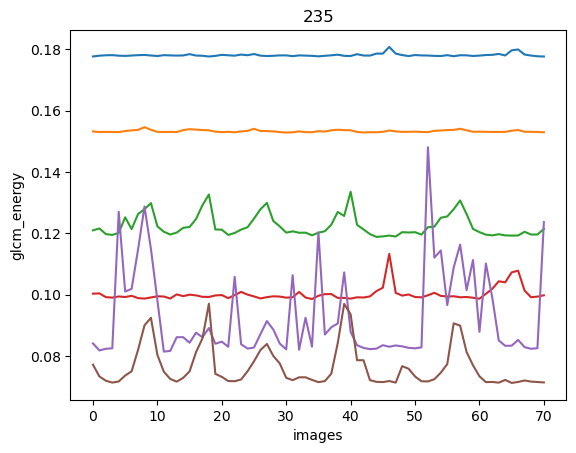

In [8]:
plt.figure()
plot_baseline_from_feature(10, 'glcm_energy')
plot_baseline_from_feature(40, 'glcm_energy')
plot_baseline_from_feature(71, 'glcm_energy')
plot_baseline_from_feature(120, 'glcm_energy')
plot_baseline_from_feature(155, 'glcm_energy')
plot_baseline_from_feature(235, 'glcm_energy')
plt.show()

## Extract features and find annomarly 

In [ ]:
def mark_mirrors_on_img(img_path, points_list):
    img_bgr = cv2.imread(str(img_path))
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

    fig, ax = plt.subplots(1, 1, figsize=(10, 8))
    ax.imshow(img_rgb)

    for points in points_list:
        # === Polygon na podstawie 4 współrzędnych ===
        polygon = patches.Polygon(
                points,
                closed=True,
                linewidth=2,
                edgecolor='red',
                facecolor='red',
                alpha=0.3  # przezroczystość wypełnienia
            )
        ax.add_patch(polygon)

    plt.tight_layout()
    plt.show()

In [15]:
def extract_features_for_mirror(
        img_gray: np.ndarray,
        mirror_extractor: SimpleMirrorExtractor,
        mirror_id: int,
) -> np.ndarray | None:
    """Extract all featues for a single mirror crop. Return None on failure."""
    try:
        crop = mirror_extractor.extract_mirror_gray(img_gray, mirror_id=mirror_id)
        glcm = extract_glcm_features(crop)
        lbp = extract_lbp_features(crop)
        edge = extract_edge_features(crop)

        vec = np.array(
            [glcm[k] for k in GLCM_KEYS]
            + [lbp[k] for k in LBP_KEYS]
            + [edge[k] for k in EDGE_KEYS],
            dtype=np.float32
        )
        return vec
    except Exception as e:
        print("Mirror %d extrraction failed: %s", mirror_id, e)
        return None

In [45]:
mirror_extractor = SimpleMirrorExtractor("/media/pgliwny/ADATA HD3303/Computer_Vision_system/data/points_WebCam.json")
img_path = "/media/pgliwny/ADATA HD3303/Computer_Vision_system/data/MAGIC/webcam_useful_images/image_2024-05-05_1300.jpg"
img = cv2.imread(str(img_path))
img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

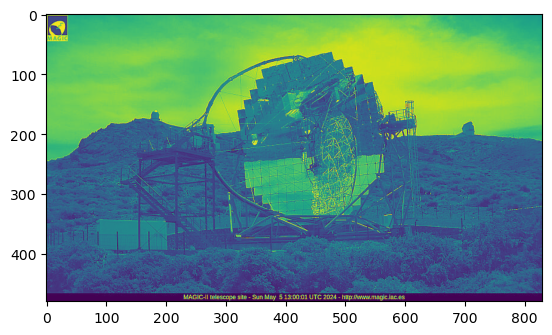

In [46]:
plt.imshow(img_gray)

In [47]:
new_features_vec = np.zeros((249, 11))
for i in range(0, 249):
    new_features_vec[i, :] = extract_features_for_mirror(img_gray, mirror_extractor, i)

In [48]:
new_features_vec 

array([[3.40056836e+03, 3.12838516e+01, 2.15262666e-01, ...,
        1.16287582e+02, 9.16792984e+01, 2.15686277e-01],
       [2.20787500e+03, 2.75923157e+01, 2.37770706e-01, ...,
        1.08463158e+02, 8.68956833e+01, 2.81578958e-01],
       [2.08896240e+03, 2.62302303e+01, 2.36005440e-01, ...,
        1.06947365e+02, 8.85498886e+01, 2.69736856e-01],
       ...,
       [4.49586523e+03, 4.77356453e+01, 6.08809479e-02, ...,
        1.26103706e+02, 8.15087585e+01, 3.14814806e-01],
       [4.64851807e+03, 4.96735954e+01, 5.09162918e-02, ...,
        1.26924370e+02, 7.49621353e+01, 3.82352948e-01],
       [2.32706787e+03, 3.29979477e+01, 8.65313485e-02, ...,
        1.36533340e+02, 7.76006241e+01, 3.03703696e-01]])

In [49]:
baseline_median = np.median(features, axis=0)
baseline_mad = np.median(
    np.abs(features - baseline_median[np.newaxis, :, :]),
    axis=0
)*1.4826

#Minum MAD żeby uniknąć dzielenia przez 0
baseline_mad = np.maximum(baseline_mad, 1e-6) #

In [50]:
z_from_baseline = (new_features_vec - baseline_median) / baseline_mad
print(np.where(z_from_baseline[:, 8] > 3.))
print(np.where(z_from_baseline[:, 8] < -2.5))

(array([], dtype=int64),)
(array([ 71,  73,  89, 148, 177, 219, 241, 242]),)
